# Day 14 — Vector databases: pgvector vs Pinecone vs Weaviate

You have embeddings and a cosine search (Day 13). A **vector database** adds the index that
makes search sublinear, plus metadata filtering, persistence, updates, and scaling. We build
the two index families that matter (**IVF** and **HNSW**) from scratch, measure the
recall/latency/memory tradeoff, then map that understanding onto the real options.

## Agenda (60 min)

| # | Segment | Time |
| - | ------- | ---- |
| 0 | What a vector DB does beyond `np.argsort` | 4 min |
| 1 | Flat index — the exact baseline | 6 min |
| 2 | IVF: cluster, then probe a few clusters | 14 min |
| 3 | HNSW: a navigable graph | 14 min |
| 4 | Metadata filtering: the hard part | 10 min |
| 5 | pgvector vs Pinecone vs Weaviate — choosing | 9 min |
| 6 | Exercises + quiz | 3 min |

Kernel: **Python (ai-upskill)**.

In [1]:
import numpy as np, time, heapq
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)
print("ready")

ready


## 0 — What a vector DB does (4 min)

| Capability | `np.argsort(D @ q)` | Vector DB |
| ---------- | ------------------- | --------- |
| Exact top-k | yes | yes (flat) |
| Sublinear search at 10⁶–10⁹ vectors | no (`O(N·d)`) | yes (ANN index) |
| Filter by metadata (`price < 50 AND lang = "en"`) | you hand-roll it | first-class |
| Insert / update / delete without full rebuild | no | yes (varies by index) |
| Persistence, replication, backups | no | yes |
| Hybrid (vector + keyword) in one query | no | some (Weaviate, others) |

The core of it is the ANN index. Build both major kinds.

In [2]:
# A synthetic corpus: 50 topic clusters in 48-dim, 8000 vectors, L2-normalised.
D_DIM, N_CLUST, PER = 48, 50, 160
centers = rng.standard_normal((N_CLUST, D_DIM))
centers /= np.linalg.norm(centers, axis=1, keepdims=True)
labels = np.repeat(np.arange(N_CLUST), PER)
X = centers[labels] + 0.14 * rng.standard_normal((N_CLUST*PER, D_DIM))
X /= np.linalg.norm(X, axis=1, keepdims=True)
N = len(X)

QN = 500
Q = centers[rng.integers(0, N_CLUST, QN)] + 0.16 * rng.standard_normal((QN, D_DIM))
Q /= np.linalg.norm(Q, axis=1, keepdims=True)

# ground truth: exact top-10 for each query
GT = np.argsort(-(Q @ X.T), axis=1)[:, :10]
print(f"{N} vectors, dim {D_DIM}, {QN} queries; ground-truth top-10 computed")

def recall_at_10(approx_neighbors):
    return np.mean([len(set(a) & set(g)) / 10 for a, g in zip(approx_neighbors, GT)])

8000 vectors, dim 48, 500 queries; ground-truth top-10 computed


## 1 — Flat index (6 min)

Store everything, score everything. Exact, simple, and the right choice up to ~10⁵–10⁶ vectors
(a brute-force matmul is very fast on modern hardware).

In [3]:
class Flat:
    def __init__(self, X): self.X = X
    def search(self, q, k=10): return np.argsort(-(self.X @ q))[:k]

flat = Flat(X)
t0 = time.perf_counter()
res = np.array([flat.search(q) for q in Q])
dt = time.perf_counter() - t0
print(f"flat: recall@10 = {recall_at_10(res):.3f}  (exact, so 1.0)")
print(f"      {1e3*dt/QN:.3f} ms/query, memory = {X.nbytes/1e6:.1f} MB")

flat: recall@10 = 1.000  (exact, so 1.0)
      0.486 ms/query, memory = 3.1 MB


## 2 — IVF: inverted file (14 min)

**Idea:** k-means the vectors into `nlist` cells. At query time, only search the `nprobe`
cells whose centroids are closest to the query. Search cost ≈ `nprobe/nlist` of flat.

In [4]:
def kmeans(X, k, iters=25, seed=0):
    r = np.random.default_rng(seed)
    C = X[r.choice(len(X), k, replace=False)].copy()
    for _ in range(iters):
        assign = np.argmax(X @ C.T, axis=1)               # cosine assignment
        for j in range(k):
            m = X[assign == j]
            if len(m): C[j] = m.mean(0) / (np.linalg.norm(m.mean(0)) + 1e-9)
    return C, np.argmax(X @ C.T, axis=1)

class IVF:
    def __init__(self, X, nlist=64):
        self.X = X
        self.C, assign = kmeans(X, nlist)
        self.lists = [np.where(assign == j)[0] for j in range(nlist)]
    def search(self, q, k=10, nprobe=4):
        cells = np.argsort(-(self.C @ q))[:nprobe]
        cand = np.concatenate([self.lists[c] for c in cells]) if len(cells) else np.array([], int)
        if len(cand) == 0: return np.array([], int)
        return cand[np.argsort(-(self.X[cand] @ q))[:k]]

ivf = IVF(X, nlist=64)
print(f"{'nprobe':>7} {'recall@10':>10} {'ms/query':>10} {'vecs scanned':>13}")
for nprobe in [1, 2, 4, 8, 16, 32]:
    t0 = time.perf_counter()
    res = [ivf.search(q, nprobe=nprobe) for q in Q]
    dt = 1e3*(time.perf_counter()-t0)/QN
    scanned = np.mean([sum(len(ivf.lists[c]) for c in np.argsort(-(ivf.C@q))[:nprobe]) for q in Q])
    # pad short results for recall calc
    padded = [np.pad(r, (0, 10-len(r)), constant_values=-1) if len(r) < 10 else r for r in res]
    print(f"{nprobe:>7} {recall_at_10(padded):>10.3f} {dt:>10.3f} {scanned:>13.0f}")

 nprobe  recall@10   ms/query  vecs scanned
      1      0.897      0.016           146
      2      0.990      0.024           263
      4      0.999      0.044           518
      8      1.000      0.087          1023


     16      1.000      0.176          2030


     32      1.000      0.366          4032


Reading it: `nprobe` is the recall/speed dial. `nprobe = nlist` reduces to flat (recall 1.0,
no speedup). Typical production: `nlist ≈ sqrt(N)` to `4·sqrt(N)`, `nprobe` tuned for ~0.95
recall. **Downsides:** needs a training step (k-means) on a sample; adding many vectors drifts
the centroids so you periodically retrain; recall is poor near cell boundaries.

## 3 — HNSW: hierarchical navigable small world (14 min)

**Idea:** build a graph where each vector links to its ~`M` nearest neighbours, plus a few
long-range links. Search = greedy walk: from an entry point, always hop to the neighbour
closest to the query, until no neighbour is closer. It's `O(log N)`-ish and needs no training.
We build a single-layer version (the real thing stacks layers for the long hops).

In [5]:
class NSW:
    def __init__(self, X, M=16, ef_construction=48):
        self.X = X; self.M = M
        self.graph = [[] for _ in range(len(X))]
        order = rng.permutation(len(X))
        self.entry = int(order[0])
        for node in order[1:]:
            found = self._search_layer(X[node], ef_construction)
            for _, p in found[:M]:
                if node not in self.graph[p]:
                    self.graph[node].append(p); self.graph[p].append(node)
            if not self.graph[node]:                       # ensure connectivity
                self.graph[node].append(self.entry); self.graph[self.entry].append(node)
    def _search_layer(self, q, ef):
        # greedy best-first search; returns up to ef (dist, idx) sorted nearest-first
        d0 = 1 - self.X[self.entry] @ q
        visited = {self.entry}
        frontier = [(d0, self.entry)]          # min-heap by distance
        result = [(d0, self.entry)]
        while frontier:
            d, cur = heapq.heappop(frontier)
            if d > result[-1][0] and len(result) >= ef:
                break
            for nb in self.graph[cur]:
                if nb in visited: continue
                visited.add(nb)
                dn = 1 - self.X[nb] @ q
                if len(result) < ef or dn < result[-1][0]:
                    heapq.heappush(frontier, (dn, nb))
                    result.append((dn, nb))
                    result.sort(); result[:] = result[:ef]
        return result
    def search(self, q, k=10, ef=32):
        return np.array([i for _, i in self._search_layer(q, max(ef, k))[:k]])

t0 = time.perf_counter(); nsw = NSW(X, M=16); build = time.perf_counter()-t0
print(f"built NSW graph in {build:.1f}s; avg degree {np.mean([len(g) for g in nsw.graph]):.1f}")
print(f"\n{'ef':>5} {'recall@10':>10} {'ms/query':>10}")
for ef in [8, 16, 32, 64, 128]:
    t0 = time.perf_counter()
    res = np.array([nsw.search(q, ef=ef) for q in Q])
    dt = 1e3*(time.perf_counter()-t0)/QN
    print(f"{ef:>5} {recall_at_10(res):>10.3f} {dt:>10.3f}")

built NSW graph in 4.8s; avg degree 32.0

   ef  recall@10   ms/query
    8      0.963      0.319


   16      0.982      0.378


   32      0.988      0.522


   64      0.997      0.858


  128      0.999      1.519


`ef` (search width) is HNSW's recall/speed dial; `M` (links per node) is set at build time and
trades index memory + build time for reachability. HNSW is the default in most vector DBs
(pgvector `hnsw`, Qdrant, Weaviate, Milvus) because it needs no training and gives high recall
at low latency. **Downsides:** memory-heavy (the graph is `O(N·M)` extra), slower to build,
deletes are awkward (tombstones + periodic rebuild).

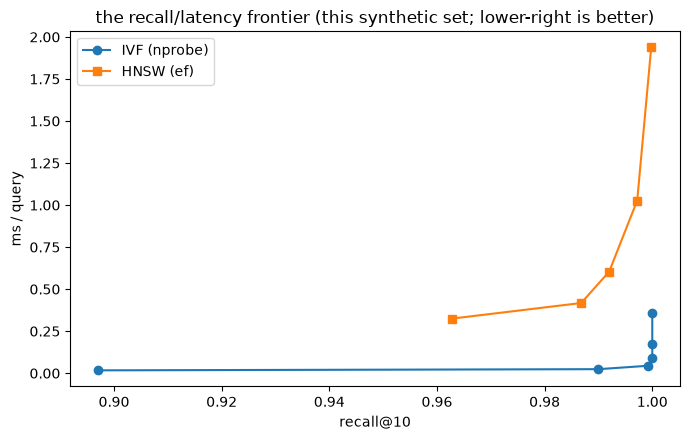

In [6]:
# the recall/latency frontier for both indexes
def curve(search_fn, dials):
    out = []
    for d in dials:
        t0 = time.perf_counter()
        r = [search_fn(q, d) for q in Q]
        dt = 1e3 * (time.perf_counter() - t0) / QN
        r = [np.pad(x, (0, 10-len(x)), constant_values=-1) if len(x) < 10 else x for x in r]
        out.append((recall_at_10(r), dt))
    return out

ci = curve(lambda q, npr: ivf.search(q, nprobe=npr), [1, 2, 4, 8, 16, 32])
cn = curve(lambda q, ef: nsw.search(q, ef=ef), [10, 20, 40, 80, 160])

plt.figure(figsize=(7, 4.5))
plt.plot([r for r, _ in ci], [t for _, t in ci], "o-", label="IVF (nprobe)")
plt.plot([r for r, _ in cn], [t for _, t in cn], "s-", label="HNSW (ef)")
plt.xlabel("recall@10"); plt.ylabel("ms / query"); plt.legend()
plt.title("the recall/latency frontier (this synthetic set; lower-right is better)")
plt.tight_layout(); plt.show()

## 4 — Metadata filtering: the hard part (10 min)

Real queries are *"nearest vectors **where** `tenant_id = 42 AND created > last_week`"*. Three
strategies, each with a failure mode:

In [7]:
meta_tenant = rng.integers(0, 10, N)          # 10 tenants
sel = 0.1                                      # query wants tenant 3 -> ~10% of corpus

def pre_filter(q, tenant, k=10):
    # filter first, then exact search the survivors
    mask = np.where(meta_tenant == tenant)[0]
    return mask[np.argsort(-(X[mask] @ q))[:k]]

def post_filter(q, tenant, k=10, fetch=10):
    # ANN search, then drop rows that fail the filter -> may return < k
    cand = nsw.search(q, k=fetch, ef=64)
    keep = [c for c in cand if meta_tenant[c] == tenant]
    return np.array(keep[:k])

def post_filter_overfetch(q, tenant, k=10):
    cand = nsw.search(q, k=200, ef=200)        # fetch way more, hope enough survive
    keep = [c for c in cand if meta_tenant[c] == tenant]
    return np.array(keep[:k])

# ground truth under the filter
qi = 0; q = Q[qi]; tenant = 3
gt_filtered = set(np.where(meta_tenant==tenant)[0][np.argsort(-(X[meta_tenant==tenant] @ q))[:10]])
for name, fn in [("pre-filter (exact)", pre_filter),
                 ("post-filter k=10", post_filter),
                 ("post-filter overfetch", post_filter_overfetch)]:
    r = fn(q, tenant)
    rec = len(set(r.tolist()) & gt_filtered)/10
    print(f"{name:24s} returned {len(r):2d}/10  recall {rec:.2f}")

pre-filter (exact)       returned 10/10  recall 1.00
post-filter k=10         returned  1/10  recall 0.10
post-filter overfetch    returned 10/10  recall 0.90


- **Pre-filter** (filter → exact search survivors): perfect recall, but if the filter matches
  millions of rows you're back to brute force.
- **Post-filter** (ANN → drop non-matching): fast, but if the filter is selective the ANN
  results are mostly filtered out and you return too few / low recall.
- **Over-fetch post-filter**: fetch `k · (1/selectivity)` candidates. Works until the filter is
  *very* selective (0.1%), then you over-fetch the whole index.
- **Filtered ANN** (what good vector DBs do): the index itself is filter-aware — Weaviate's
  inverted-index pre-filter feeding the HNSW walk, Qdrant's payload index, pgvector + a
  B-tree + `iterative` scan. This is a real differentiator between products.

## 5 — Choosing: pgvector vs Pinecone vs Weaviate (9 min)

| | **pgvector** | **Pinecone** | **Weaviate** |
| --- | --- | --- | --- |
| What | Postgres extension | Managed SaaS only | OSS engine, self-host or cloud |
| Index | ivfflat, hnsw | proprietary (serverless) | hnsw (+ flat) |
| Scale (comfortable) | ~1–10 M rows / node | 100 M–1 B+ | 10–100 M+ / node |
| Filtering | SQL `WHERE` (+ iterative index scan) | metadata filters, good | inverted-index pre-filter, very good |
| Hybrid keyword+vector | `tsvector` + manual fusion | sparse-dense (recent) | **built in** (BM25 + vector) |
| Ops burden | you run Postgres (or RDS/Aurora) | zero (fully managed) | medium (or use their cloud) |
| Transactions / joins with your data | **yes — it's Postgres** | no | limited |
| Cost shape | your DB instance | per-usage, gets pricey at scale | your infra, or their cloud |
| Lock-in | none (SQL) | high (proprietary API) | low (OSS, portable) |

### The decision tree

1. **Already on Postgres, < a few million vectors, want joins/transactions with your
   relational data?** → **pgvector.** Don't add a system you don't need. (This is most apps.)
2. **Need to scale past ~10–50 M vectors, or want zero ops and predictable managed
   behaviour?** → **Pinecone** (or Turbopuffer, or pgvector on Aurora with read replicas).
3. **Want first-class hybrid search, an OSS engine you can self-host, or built-in
   embedding/reranker modules?** → **Weaviate** (or Qdrant — similar niche, Rust, great
   filtering).
4. **Prototyping locally / notebook / small app?** → **Chroma** or FAISS or LanceDB.

### Also in the running

- **Qdrant** — Rust, excellent filtered search, OSS + cloud. Strong pgvector alternative.
- **Milvus** — heavy, distributed, for very large scale.
- **FAISS** — a library not a DB (no persistence/filtering out of the box); the engine inside
  many others.
- **Turbopuffer / LanceDB** — object-storage-backed, cheap at rest, newer.

### What actually matters in practice

Recall@k on *your* data, p95 latency at *your* filter selectivity, cost at *your* scale, and
whether it fits your existing ops. Benchmark two candidates on your workload (Day 12 method) —
public benchmarks (ann-benchmarks.com) are a starting shortlist only.

## 6 — Exercises

1. **nlist sweep.** Rebuild `IVF` with `nlist in [16, 64, 256]`. For each, find the `nprobe`
   that first reaches recall ≥ 0.95 and report vecs-scanned. Which `nlist` is most efficient
   at that recall?
2. **HNSW memory.** Compute the graph's extra memory (`sum(len(g)) * 4 bytes` for int32 ids)
   as a fraction of the raw vector memory, for `M in [8, 16, 32]`. Plot memory vs recall@10
   (at `ef=64`).
3. **The boundary problem.** Find queries where IVF (`nprobe=1`) recall is 0 but HNSW recall
   is 1. Show these queries sit near a cluster boundary (their top-10 GT spans ≥ 2 k-means
   cells).
4. **Filter selectivity curve.** Vary tenant-filter selectivity from 0.5 down to 0.01 (make
   more tenants). Plot `post_filter` recall and result-count vs selectivity. Where does it
   break?
5. **Over-fetch factor.** For `post_filter_overfetch`, derive the fetch size needed for
   E[survivors] ≥ k given selectivity `s`: `fetch ≥ k / s · safety`. Verify empirically for
   `s = 0.1`.
6. **Pick a DB.** For each: (a) a Rails app with 200k product embeddings and lots of
   `WHERE category = ... AND in_stock`; (b) a RAG service expecting 500M chunks and spiky
   traffic; (c) a search feature needing BM25+vector in one call over 5M docs. Name the DB and
   one runner-up.

> **Attempt every exercise and the quiz first.** The worked solutions and the answer key live in [`solutions/solutions.ipynb`](solutions/solutions.ipynb) — open it only to check your work, not to start.

## Self-check quiz


1. Up to roughly how many vectors is a flat (brute-force) index the right choice, and why?
2. What is IVF's `nprobe`, and what does setting `nprobe = nlist` do?
3. Why does IVF need periodic retraining but HNSW does not?
4. What are HNSW's `M` and `ef`, and which is fixed at build time?
5. Explain the failure mode of post-filtering with a selective metadata filter.
6. You're on Postgres with 800k vectors and heavy relational filters. Which vector DB, and why
   not one of the others?
7. Name the one thing you should measure on your own workload before committing to a vector DB.

## Where this goes next

- **Day 15 — pgvector hands-on:** the SQL side — `CREATE EXTENSION vector`, the `<->` / `<=>`
  operators, building an `ivfflat` / `hnsw` index, similarity queries with `WHERE` filters,
  and the full script to run it on AWS RDS.